# Eda службы поддержки

Ноутбук показывает базовый анализ обращений: качество данных, sla, backlog, нагрузку агентов и категории с повышенным риском.

In [10]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

root = Path('..')
processed = root / 'data' / 'processed'
marts = root / 'data' / 'marts'

In [11]:
tickets = pd.read_csv(processed / 'tickets.csv', parse_dates=['created_at', 'first_response_at', 'closed_at'])
agents = pd.read_csv(processed / 'agents.csv')
departments = pd.read_csv(processed / 'departments.csv')
quality = pd.read_csv(processed / 'data_quality_summary.csv')
tickets.head()

,ticket_id,created_at,first_response_at,closed_at,status,priority,category,channel,agent_id,department_id,customer_segment_id,sla_target_hours,sla_breached,first_response_hours,resolution_hours,satisfaction_score
0,tck_000001,2025-10-01 07:27:00,2025-10-02 01:18:00,2025-10-03 21:57:00,closed,low,bug report,portal,agt_017,dep_01,seg_03,96,0,17.86,62.51,4.5
1,tck_000002,2025-10-01 11:09:00,2025-10-01 12:12:00,2025-10-01 15:13:00,closed,high,billing question,phone,agt_006,dep_02,seg_01,13,0,1.07,4.07,4.8
2,tck_000003,2025-10-01 14:55:00,2025-10-01 15:41:00,2025-10-01 19:11:00,closed,critical,billing question,chat,agt_007,dep_02,seg_02,7,0,0.78,4.28,4.8
3,tck_000004,2025-10-01 09:46:00,2025-10-02 05:43:00,2025-10-03 23:14:00,closed,low,bug report,portal,agt_004,dep_01,seg_05,129,0,19.97,61.47,5.0
4,tck_000005,2025-10-01 09:31:00,2025-10-01 21:34:00,2025-10-03 17:42:00,closed,low,integration issue,chat,agt_015,dep_05,seg_04,115,0,12.06,56.19,4.8


## Проверка качества

Сначала смотрим автоматические проверки и базовые пропуски.

In [12]:
quality

,table_name,check_name,issue_count,result
0,tickets,duplicate ticket_id,0,pass
1,tickets,missing required values,0,pass
2,tickets,invalid dates,0,pass
3,tickets,negative durations,0,pass
4,ticket_events,duplicate event_id,0,pass
5,ticket_events,missing required values,0,pass
6,ticket_events,invalid event dates,0,pass
7,agents,duplicate agent_id,0,pass
8,departments,duplicate department_id,0,pass
9,customer_segments,duplicate customer_segment_id,0,pass


In [13]:
tickets.isna().mean().sort_values(ascending=False).head(10)

closed_at             0.044978
satisfaction_score    0.044978
created_at            0.000000
ticket_id             0.000000
status                0.000000
priority              0.000000
category              0.000000
first_response_at     0.000000
channel               0.000000
agent_id              0.000000
dtype: float64

## Объем обращений

Проверяем недельный ритм и всплески нагрузки.

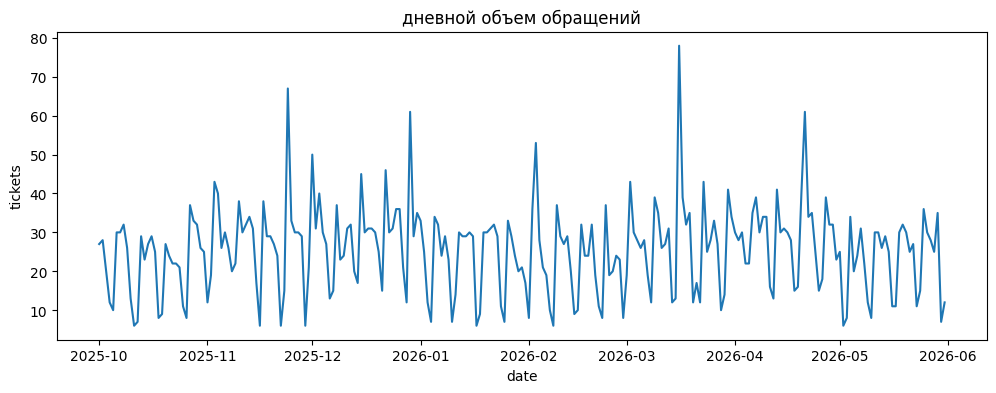

In [14]:
daily_volume = tickets.assign(date=tickets['created_at'].dt.date).groupby('date').size()
daily_volume.plot(figsize=(12, 4), title='дневной объем обращений')
plt.ylabel('tickets')
plt.show()

## Sla

Смотрим долю нарушений по приоритетам и категориям.

In [15]:
sla_by_priority = tickets.groupby('priority')['sla_breached'].agg(['count', 'mean']).sort_values('mean', ascending=False)
sla_by_priority

,count,mean
priority,,
critical,387,0.521964
high,1266,0.430490
medium,2816,0.248224
low,1734,0.143599


In [16]:
sla_by_category = tickets.groupby('category')['sla_breached'].agg(['count', 'mean']).sort_values('mean', ascending=False)
sla_by_category.head(10)

,count,mean
category,,
integration issue,674,0.602374
abuse report,295,0.457627
bug report,1067,0.407685
data export,310,0.338710
invoice dispute,544,0.283088
feature request,569,0.267135
onboarding help,719,0.143255
login access,1005,0.109453
billing question,1020,0.093137


## Backlog

Используем готовую витрину, чтобы оценить рост открытых обращений.

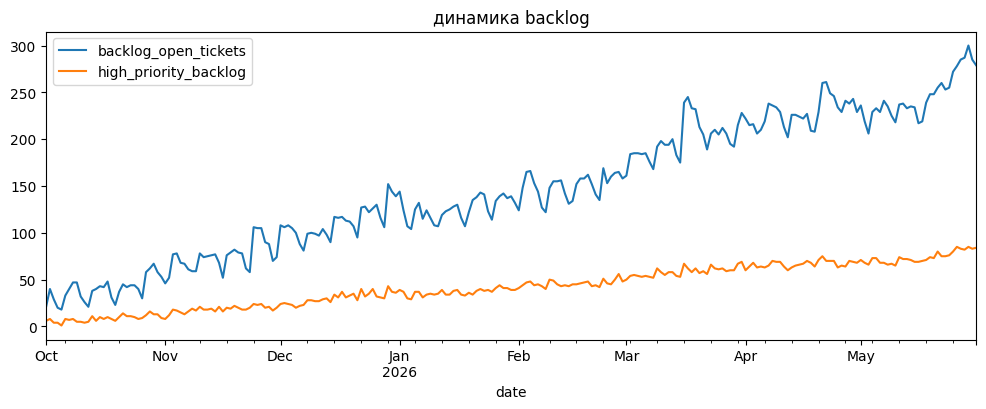

In [17]:
backlog = pd.read_csv(marts / 'mart_backlog.csv', parse_dates=['date'])
backlog.plot(x='date', y=['backlog_open_tickets', 'high_priority_backlog'], figsize=(12, 4))
plt.title('динамика backlog')
plt.show()

## Нагрузка агентов

Проверяем, как распределяется работа между агентами и где виден перегруз.

In [18]:
workload = pd.read_csv(marts / 'mart_workload.csv')
agent_summary = workload.groupby(['agent_name', 'is_overloaded_group']).agg(
    assigned_tickets=('assigned_tickets', 'sum'),
    open_backlog=('open_backlog', 'mean'),
    sla_breach_rate=('sla_breach_rate', 'mean'),
    avg_satisfaction_score=('avg_satisfaction_score', 'mean'),
).sort_values('assigned_tickets', ascending=False)
agent_summary.head(12)

,,assigned_tickets,open_backlog,sla_breach_rate,avg_satisfaction_score
agent_name,is_overloaded_group,,,,
elena fedorova,yes,669,12.074074,0.153909,3.960741
anna petrova,yes,506,11.609053,0.256708,3.602757
kirill egorov,no,497,7.724280,0.075514,3.733045
egor karpov,no,458,10.551440,0.188889,3.446132
maria zaitseva,yes,433,10.337449,0.163251,3.530782
pavel morozov,no,424,6.983539,0.166420,3.490823
irina volkova,yes,411,16.477366,0.453704,2.989877
natalia kuzmina,no,398,6.674897,0.130494,3.373909
mikhail orlov,no,378,9.736626,0.141687,3.417572


## Ключевые выводы

- Недельная сезонность задает основной ритм нагрузки.
- Категории с высокой сложностью чаще нарушают sla.
- Перегруженные агенты получают больше обращений и могут накапливать backlog.
- Удовлетворенность чувствительна к долгому решению и нарушению sla.